In [1]:
import pandas as pd
import numpy as np

In [2]:
# till now
# Timestamp
print(pd.Timestamp('6th jan 2023 8:10'))
print(pd.Timestamp('2023-01-06')) # YYYY-MM-DD
print(pd.Timestamp.now())
print(pd.Timestamp.today())

# DatetimeIndex -> df and series index
dates = pd.DatetimeIndex([
    pd.Timestamp('6th jan 2023 8:10'), 
    pd.Timestamp('7th jan 2023 8:10'), 
    pd.Timestamp('8th jan 2023 8:10')
])
# print(dates)

# using as index
df = pd.DataFrame(
    {'sales':[100,200,300]},
    index=dates
)
print('\nNew DataFrame------------\n',df)


# date_range() -> Creates a squence of dates
datewise = pd.date_range(
    start='2023-01-01',
    end='2023-01-10',
    freq='D'
)
print(datewise)
pd.date_range(
    start='2023-01-01',
    periods=12,
    freq='M'
)


# to_datetime() -> Most imp function => Converts strings into datetime objects.
s = pd.Series([
    '2023-01-01',
    '2023-02-15',
    '2023-03-20'
])
pd.to_datetime(s)

s = pd.Series([
    '01/01/2023',
    '15/02/2023',
    '20/03/2023'
])

pd.to_datetime(s, dayfirst=True)

2023-01-06 08:10:00
2023-01-06 00:00:00
2026-06-19 15:31:31.168796
2026-06-19 15:31:31.168908

New DataFrame------------
                      sales
2023-01-06 08:10:00    100
2023-01-07 08:10:00    200
2023-01-08 08:10:00    300
DatetimeIndex(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04',
               '2023-01-05', '2023-01-06', '2023-01-07', '2023-01-08',
               '2023-01-09', '2023-01-10'],
              dtype='datetime64[ns]', freq='D')


C:\Users\hites\AppData\Local\Temp\ipykernel_6440\648699788.py:31: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.date_range(


0   2023-01-01
1   2023-02-15
2   2023-03-20
dtype: datetime64[ns]

In [3]:
# to_datetime()
s = pd.Series(['2023/1/6','2023/1/7','2023/1/7'])
pd.to_datetime(s).dt.year
pd.to_datetime(s).dt.month_name()
pd.to_datetime(s).dt.day_name()

0      Friday
1    Saturday
2    Saturday
dtype: object

### Timedelta Object
- Represents a duration, the difference between two dates or times

In [4]:
# create using Timestamp Objects
t1 = pd.Timestamp('6th Jan 2023 08:20:14')
t2 = pd.Timestamp('26th Jan 2023 10:00:00')

t2 - t1

Timedelta('20 days 01:39:46')

In [5]:
t1 - t2

Timedelta('-21 days +22:20:14')

In [6]:
# standalone creation
pd.Timedelta(days=2)

Timedelta('2 days 00:00:00')

In [7]:
pd.Timedelta(days=2,hours=10,minutes=35)

Timedelta('2 days 10:35:00')

In [8]:
# Arithmetic
pd.Timestamp('6th Jan 2023') + pd.Timedelta(days=2,hours=10,minutes=35)

Timestamp('2023-01-08 10:35:00')

In [9]:
pd.date_range(
    start='2023-1-6',
    end='2023-1-31',
    freq='D'
) + pd.Timedelta(days=2,hours=10,minutes=35)

DatetimeIndex(['2023-01-08 10:35:00', '2023-01-09 10:35:00',
               '2023-01-10 10:35:00', '2023-01-11 10:35:00',
               '2023-01-12 10:35:00', '2023-01-13 10:35:00',
               '2023-01-14 10:35:00', '2023-01-15 10:35:00',
               '2023-01-16 10:35:00', '2023-01-17 10:35:00',
               '2023-01-18 10:35:00', '2023-01-19 10:35:00',
               '2023-01-20 10:35:00', '2023-01-21 10:35:00',
               '2023-01-22 10:35:00', '2023-01-23 10:35:00',
               '2023-01-24 10:35:00', '2023-01-25 10:35:00',
               '2023-01-26 10:35:00', '2023-01-27 10:35:00',
               '2023-01-28 10:35:00', '2023-01-29 10:35:00',
               '2023-01-30 10:35:00', '2023-01-31 10:35:00',
               '2023-02-01 10:35:00', '2023-02-02 10:35:00'],
              dtype='datetime64[ns]', freq='D')

In [10]:
# real life example
df = pd.read_csv('deliveries (1).csv')
df.head()

,order_date,delivery_date
0,5/24/98,2/5/99
1,4/22/92,3/6/98
2,2/10/91,8/26/92
3,7/21/92,11/20/97
4,9/2/93,6/10/98


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   order_date     501 non-null    object
 1   delivery_date  501 non-null    object
dtypes: object(2)
memory usage: 8.0+ KB


In [17]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['delivery_date'] = pd.to_datetime(df['delivery_date'])

C:\Users\hites\AppData\Local\Temp\ipykernel_6440\3472121163.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['delivery_date'] = pd.to_datetime(df['delivery_date'])


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 501 entries, 0 to 500
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_date     501 non-null    datetime64[ns]
 1   delivery_date  501 non-null    datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 8.0 KB


In [21]:
df['delivery_time_period'] = df['delivery_date'] - df['order_date']
df.head()

,order_date,delivery_date,delivery_time_period
0,1998-05-24,1999-02-05,257 days
1,1992-04-22,1998-03-06,2144 days
2,1991-02-10,1992-08-26,563 days
3,1992-07-21,1997-11-20,1948 days
4,1993-09-02,1998-06-10,1742 days


In [22]:
df['delivery_time_period'].mean()

Timedelta('1217 days 22:53:53.532934128')

### Time Series
- A time series is a data set that tracks a sample over time. In particular, a time series allows one to see what factor influence certain variables from period to period.
- Time series analysis can be useful to see how a given asset, security, or economic variable changes over time.
- Examples
    - Financial Data (Company Stocks).
    - Natural Data (Rainfall Measurnment).
    - Event Data (Covid).
    - Medical Data (Heart Rate Monitoring)
- Types of Operations done on Time Series
    - Time Series Analysis
    - Time Series Forecasting

In [23]:
google = pd.read_csv('google.csv')
google.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361
1,2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874
2,2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897
3,2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808
4,2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276


In [24]:
google.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
4466,2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100
4467,2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800
4468,2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100
4469,2022-05-19,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600
4470,2022-05-20,2241.709961,2251.000000,2127.459961,2186.260010,2186.260010,1878100


In [26]:
google.info()
google['Date'] = pd.to_datetime(google['Date'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4471 entries, 0 to 4470
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4471 non-null   object 
 1   Open       4471 non-null   float64
 2   High       4471 non-null   float64
 3   Low        4471 non-null   float64
 4   Close      4471 non-null   float64
 5   Adj Close  4471 non-null   float64
 6   Volume     4471 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 244.6+ KB


In [27]:
google.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4471 entries, 0 to 4470
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4471 non-null   datetime64[ns]
 1   Open       4471 non-null   float64       
 2   High       4471 non-null   float64       
 3   Low        4471 non-null   float64       
 4   Close      4471 non-null   float64       
 5   Adj Close  4471 non-null   float64       
 6   Volume     4471 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 244.6 KB


In [ ]:
google.set_index('Date',inplace=True)


KeyError: "None of ['Date'] are in the columns"

In [36]:
google.head(7)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276
2004-08-26,52.279045,53.773445,52.134586,53.753517,53.753517,7128620
2004-08-27,53.848164,54.107193,52.647663,52.876804,52.876804,6241307


In [35]:
# fetch a specific date
google.loc['2022-2-03']

Open         2.905900e+03
High         2.982354e+03
Low          2.844100e+03
Close        2.853010e+03
Adj Close    2.853010e+03
Volume       2.846500e+06
Name: 2022-02-03 00:00:00, dtype: float64

In [38]:
# partial indexing -> select a particular year/month
google.loc['2021-12'] # all the dates of 2021 year 12th month

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-12-01,2884.250000,2929.982910,2830.000000,2832.360107,2832.360107,1423800
2021-12-02,2836.479980,2893.500000,2819.639893,2875.530029,2875.530029,1062500
2021-12-03,2889.909912,2904.260010,2823.000000,2850.409912,2850.409912,1334400
2021-12-06,2871.479980,2887.030029,2812.939941,2875.929932,2875.929932,1109900
2021-12-07,2919.000000,2966.000000,2914.050049,2960.729980,2960.729980,1162900
2021-12-08,2966.629883,2983.129883,2944.000000,2974.409912,2974.409912,948200
2021-12-09,2963.520020,2992.100098,2950.580078,2962.120117,2962.120117,929000
2021-12-10,2982.000000,2988.000000,2947.149902,2973.500000,2973.500000,1081700
2021-12-13,2968.879883,2971.250000,2927.199951,2934.090088,2934.090088,1205200


In [39]:
google.loc['2022']

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-01-03,2889.510010,2911.000000,2870.050049,2901.489990,2901.489990,1260700
2022-01-04,2911.010010,2932.199951,2876.322998,2888.330078,2888.330078,1146400
2022-01-05,2883.620117,2885.959961,2750.469971,2753.070068,2753.070068,2482100
2022-01-06,2749.949951,2793.719971,2735.270020,2751.020020,2751.020020,1452500
2022-01-07,2758.100098,2765.094971,2715.780029,2740.090088,2740.090088,970400
...,...,...,...,...,...,...
2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100
2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800
2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100


In [43]:
# create your month-name and day-name
google['month_name'] = google.index.month_name()
google['weekday_name'] = google.index.day_name()
google['quarter'] = google.index.quarter
google

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897,August,Monday,3
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808,August,Tuesday,3
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276,August,Wednesday,3
...,...,...,...,...,...,...,...,...,...
2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100,May,Monday,2
2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800,May,Tuesday,2
2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100,May,Wednesday,2


In [45]:
# slicing
google.loc['2019-12-15' : '2020-1-1':2]

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2019-12-16,1356.500000,1364.680054,1352.670044,1361.170044,1361.170044,1397300,December,Monday,4
2019-12-18,1356.599976,1360.469971,1351.000000,1352.619995,1352.619995,1522600,December,Wednesday,4
2019-12-20,1363.349976,1363.640015,1349.000000,1349.589966,1349.589966,3315000,December,Friday,4
2019-12-24,1348.500000,1350.260010,1342.780029,1343.560059,1343.560059,347500,December,Tuesday,4
2019-12-27,1362.989990,1364.530029,1349.310059,1351.890015,1351.890015,1038400,December,Friday,4
2019-12-31,1330.109985,1338.000000,1329.084961,1337.020020,1337.020020,961800,December,Tuesday,4


In [57]:
# challenge -> fecth info for a particular date every year -> limitation timedelta
google[google.index.isin(pd.date_range( start='2005-1-6', end='2022 -1-6',freq=pd.DateOffset(years=1)))]
    

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2005-01-06,97.175758,97.584229,93.509506,93.922951,93.922951,20852067,January,Thursday,1
2006-01-06,227.581970,234.371521,225.773743,231.960556,231.960556,35646914,January,Friday,1
2009-01-06,165.868286,169.763687,162.585587,166.406265,166.406265,12898566,January,Tuesday,1
2010-01-06,311.761444,311.761444,302.047852,302.994293,302.994293,7987226,January,Wednesday,1
2011-01-06,304.199799,308.060303,303.885956,305.604523,305.604523,4131026,January,Thursday,1
2012-01-06,328.344299,328.767700,323.681763,323.796326,323.796326,5405987,January,Friday,1
2014-01-06,554.426880,557.340942,551.154114,556.573853,556.573853,3551864,January,Monday,1
2015-01-06,513.589966,514.761719,499.678131,500.585632,500.585632,2899940,January,Tuesday,1
2016-01-06,730.000000,747.179993,728.919983,743.619995,743.619995,1947000,January,Wednesday,1


<Axes: xlabel='Date'>

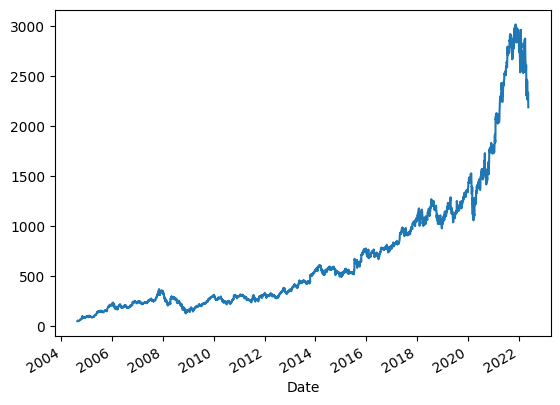

In [59]:
# viz a single col
google['Close'].plot()

In [62]:
# viz all columns together
google.head()
subset = google[['Open','High','Low','Close']]

In [63]:
import seaborn as sns

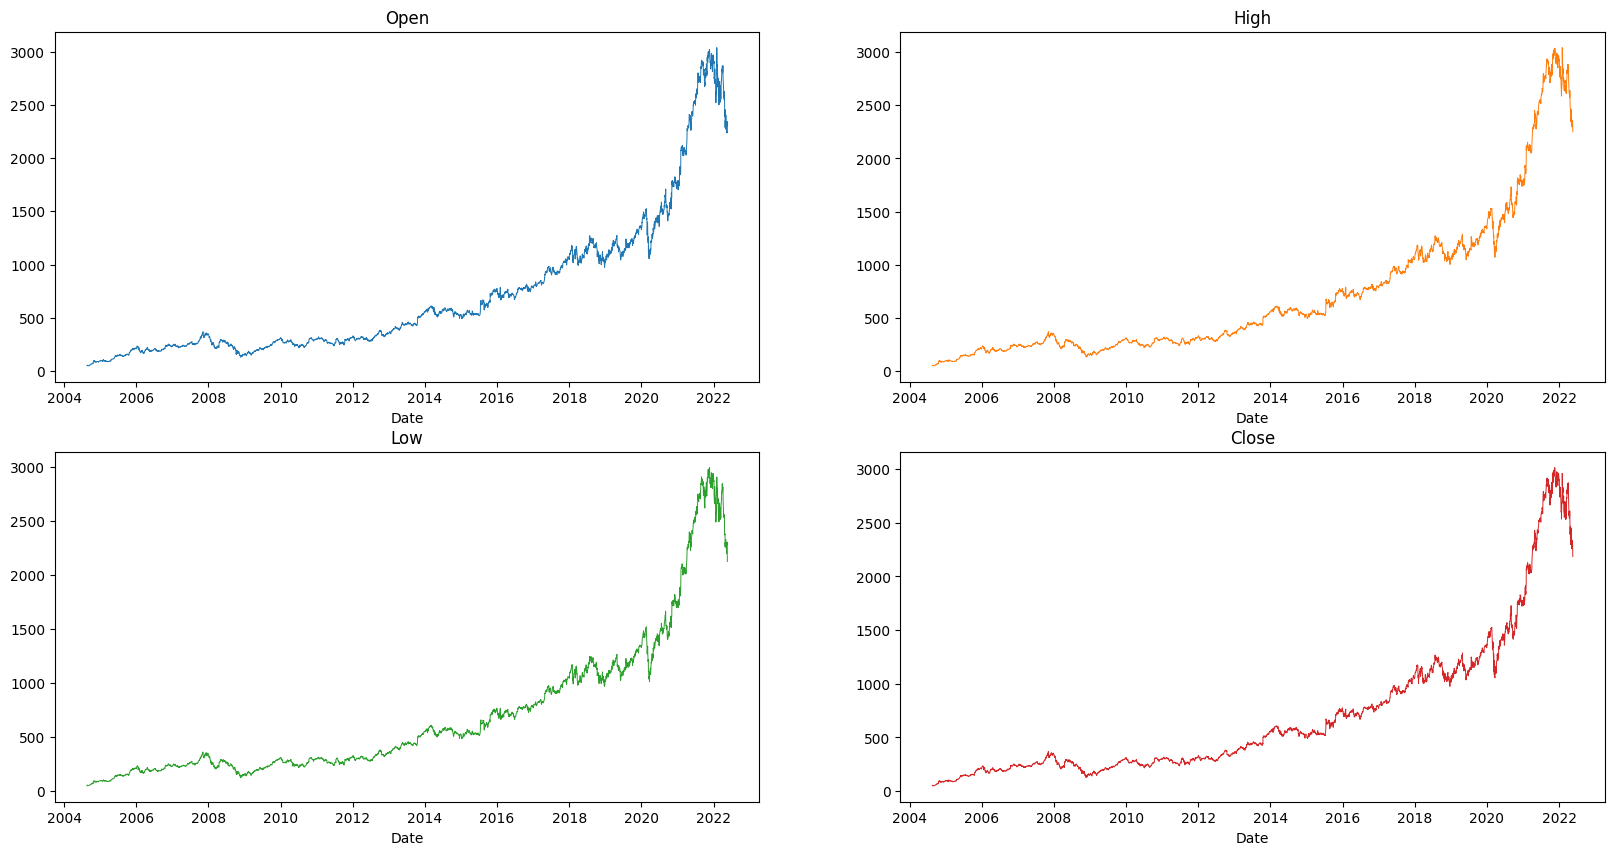

In [64]:
ax = subset.plot(subplots=True,
                 layout=(2,2),
                 sharex=False,
                 sharey=False,
                 linewidth=0.7,
                 fontsize=10,
                 legend=False,
                 figsize=(20,10),
                 title=['Open','High','Low','Close'])

<Axes: xlabel='Date'>

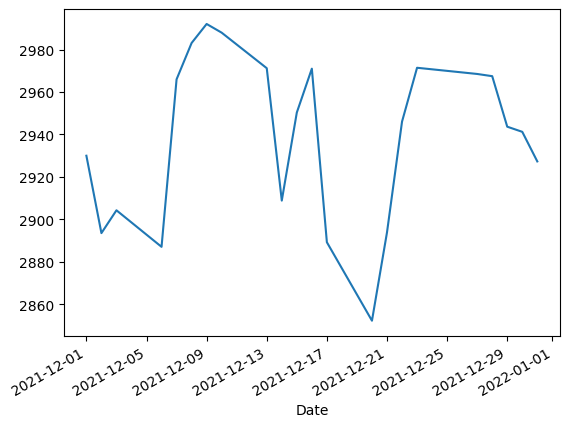

In [66]:
# plot for a particular year / month / week
google.loc['2021-12']['High'].plot()

<Axes: xlabel='month_name'>

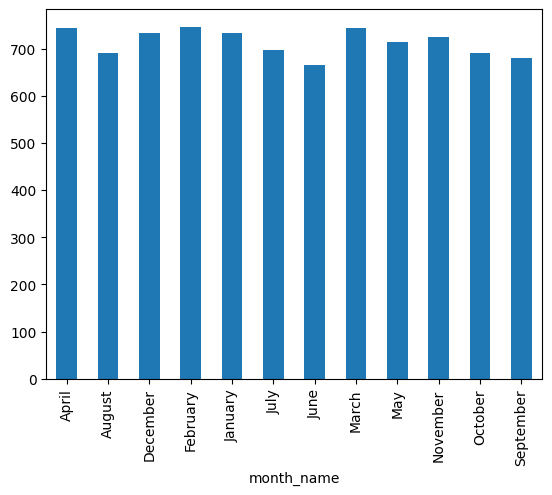

In [67]:
# monthly trend
google.groupby('month_name')['High'].mean().plot(kind='bar')

<Axes: xlabel='weekday_name'>

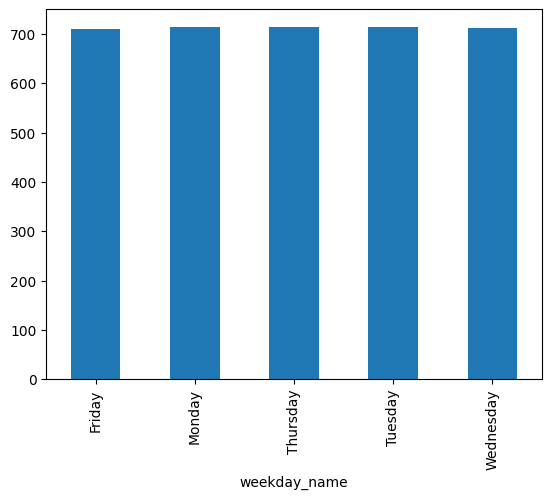

In [68]:
# Yearly trend
google.groupby('weekday_name')['High'].mean().plot(kind='bar')

In [69]:
# frequency
google.index

DatetimeIndex(['2004-08-19', '2004-08-20', '2004-08-23', '2004-08-24',
               '2004-08-25', '2004-08-26', '2004-08-27', '2004-08-30',
               '2004-08-31', '2004-09-01',
               ...
               '2022-05-09', '2022-05-10', '2022-05-11', '2022-05-12',
               '2022-05-13', '2022-05-16', '2022-05-17', '2022-05-18',
               '2022-05-19', '2022-05-20'],
              dtype='datetime64[ns]', name='Date', length=4471, freq=None)

In [73]:
# asfreq
google.asfreq('D')

,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361.0,August,Thursday,3.0
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874.0,August,Friday,3.0
2004-08-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-08-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897.0,August,Monday,3.0
...,...,...,...,...,...,...,...,...,...
2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100.0,May,Monday,2.0
2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800.0,May,Tuesday,2.0
2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100.0,May,Wednesday,2.0


In [74]:
google.asfreq('6H',method='bfill')

C:\Users\hites\AppData\Local\Temp\ipykernel_6440\360706465.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  google.asfreq('6H',method='bfill')


,Open,High,Low,Close,Adj Close,Volume,month_name,weekday_name,quarter
Date,,,,,,,,,
2004-08-19 00:00:00,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-19 06:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
2004-08-19 12:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
2004-08-19 18:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
2004-08-20 00:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
...,...,...,...,...,...,...,...,...,...
2022-05-19 00:00:00,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600,May,Thursday,2
2022-05-19 06:00:00,2241.709961,2251.000000,2127.459961,2186.260010,2186.260010,1878100,May,Friday,2
2022-05-19 12:00:00,2241.709961,2251.000000,2127.459961,2186.260010,2186.260010,1878100,May,Friday,2


### Resampling
- Resampling involves changing the frequency of your time series observations.
- Two types of resampling are :-
    - **Upsampling :-** Where you increase the frequency of samples, such as from minutes to seconds.
    - **Downsampling :-** When you decrease the frequency of the samples, such as from days to months.

C:\Users\hites\AppData\Local\Temp\ipykernel_6440\2795811670.py:3: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  google['Close'].resample('Y').mean().plot()


<Axes: xlabel='Date'>

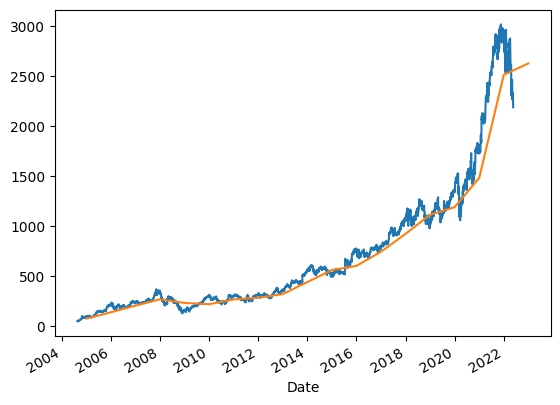

In [81]:
# Upsampling
google['Close'].plot()
google['Close'].resample('Y').mean().plot()

### Rolling Window (Smoothing)
- Time series data in original format can be quite volatile, especially on smaller aggregation levels. The concept of rolling, or moving averages is a useful technique for smoothing time series data.

<Axes: title={'center': 'ewm'}, xlabel='Date'>

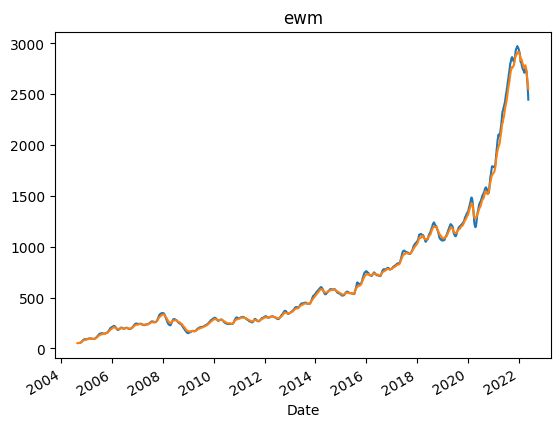

In [86]:
# Rolling window
google['High'].rolling(30).mean().plot(title='rolling')
google['High'].ewm(30).mean().plot(title='ewm')

### Shifting

The shift() function is Pandas is used to, well, shift the entire series up or down by the desired number of periods.

In [87]:
google['Close']

Date
2004-08-19      49.982655
2004-08-20      53.952770
2004-08-23      54.495735
2004-08-24      52.239197
2004-08-25      52.802086
                 ...     
2022-05-16    2295.850098
2022-05-17    2334.030029
2022-05-18    2248.020020
2022-05-19    2214.909912
2022-05-20    2186.260010
Name: Close, Length: 4471, dtype: float64

In [97]:
google['Close'].shift(1)

Date
2004-08-19            NaN
2004-08-20      49.982655
2004-08-23      53.952770
2004-08-24      54.495735
2004-08-25      52.239197
                 ...     
2022-05-16    2330.310059
2022-05-17    2295.850098
2022-05-18    2334.030029
2022-05-19    2248.020020
2022-05-20    2214.909912
Name: Close, Length: 4471, dtype: float64

In [99]:
# shift example
df = pd.read_csv('login.csv',header=None)
df = df[[1,2]]
df.head()
df.rename(columns={1:'user_id',2:'login_time'},inplace=True)
df.head()

,user_id,login_time
0,466,2017-01-07 18:24:07
1,466,2017-01-07 18:24:55
2,458,2017-01-07 18:25:18
3,458,2017-01-07 18:26:21
4,592,2017-01-07 19:09:59


In [100]:
user_df = df[df['user_id'] == 458]
user_df.head()

,user_id,login_time
2,458,2017-01-07 18:25:18
3,458,2017-01-07 18:26:21
9,458,2017-01-09 11:13:12
10,458,2017-01-09 11:34:02
25,458,2017-01-10 12:14:11


In [101]:
user_df['login_time'] = pd.to_datetime(user_df['login_time'])
user_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 2 to 1018
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     208 non-null    int64         
 1   login_time  208 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 4.9 KB


C:\Users\hites\AppData\Local\Temp\ipykernel_6440\897488481.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['login_time'] = pd.to_datetime(user_df['login_time'])


In [105]:
user_df['shifted'] = user_df['login_time'].shift(1)
user_df.head()
(user_df['login_time'] - user_df['shifted']).mean()

C:\Users\hites\AppData\Local\Temp\ipykernel_6440\2655648305.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['shifted'] = user_df['login_time'].shift(1)


Timedelta('0 days 17:29:22.053140096')